# Nascimentos: perfil dos nascidos vivos

**Pergunta que este notebook responde:** quantos bebês nasceram no estado, qual
a proporção de cesáreas, o peso ao nascer e a cobertura de pré-natal?

**Fonte:** SINASC — Sistema de Informações sobre Nascidos Vivos (declarações de
nascido vivo).
**Tempo estimado:** 3 a 5 minutos.

> Como no SIM, **não** se passa `group` nesta base.

## Preparação

In [2]:
%pip install pysus==2.10.6 nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

In [3]:
UF = "PR"
ANO = 2022    # o SINASC também tem defasagem de publicação

## Passo 1 — Conferir o que existe

In [4]:
from pysus import list_files

catalogo = list_files(dataset="sinasc", state=UF)
anos = sorted({int(a) for a in catalogo["year"].dropna()})

print(f"Anos disponíveis para {UF}: {anos[-10:]}")
print(f"{ANO} disponível? {'sim' if ANO in anos else 'NÃO — escolha outro ano'}")

Anos disponíveis para PR: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
2022 disponível? sim


## Passo 2 — Baixar os nascimentos

### ⚠️ Uma armadilha do `state=`

O parâmetro `state=` diz à PySUS **qual estado procurar**, mas ele **não filtra
o resultado**. Desde 2026 o catálogo do DATASUS publica, ao lado do arquivo de
cada estado, um arquivo **nacional** — e a PySUS devolve os dois. Somados, eles
trazem o Brasil inteiro e ainda contam o seu estado **duas vezes**.

A célula abaixo resolve isso de uma vez: fica com o arquivo do próprio estado
(o catálogo sabe distinguir — o nacional vem sem estado) e, se o ano só tiver o
arquivo nacional, filtra pelo código do IBGE e avisa que fez isso.

> Procurar a sigla no nome do arquivo **não** funciona: `DO23OPEN` contém "PE".

In [5]:
import pathlib
import pandas as pd
from pysus import list_files

CODIGO_UF = {
    "RO": "11", "AC": "12", "AM": "13", "RR": "14", "PA": "15", "AP": "16",
    "TO": "17", "MA": "21", "PI": "22", "CE": "23", "RN": "24", "PB": "25",
    "PE": "26", "AL": "27", "SE": "28", "BA": "29", "MG": "31", "ES": "32",
    "RJ": "33", "SP": "35", "PR": "41", "SC": "42", "RS": "43", "MS": "50",
    "MT": "51", "GO": "52", "DF": "53",
}


def baixar_do_estado(nome_base, funcao, uf, ano, coluna_municipio="CODMUNRES"):
    """Baixa a base e garante que só sobre o estado pedido."""
    catalogo = list_files(dataset=nome_base, state=uf, year=ano)
    do_estado = {
        pathlib.Path(str(n)).name
        for n in catalogo.loc[catalogo["state"] == uf, "name"]
    }
    caminhos = funcao(state=uf, year=ano)
    escolhidos = [p for p in caminhos if pathlib.Path(str(p)).name in do_estado]

    if escolhidos:
        df = pd.concat([pd.read_parquet(p) for p in escolhidos], ignore_index=True)
    else:
        df = pd.concat([pd.read_parquet(p) for p in caminhos], ignore_index=True)
        antes = len(df)
        df = df[df[coluna_municipio].astype(str).str[:2] == CODIGO_UF[uf]]
        print(f"  (este ano só tem arquivo nacional: filtrei {antes:,} linhas "
              f"do país para {len(df):,} de {uf})")
    return df.reset_index(drop=True)

from pysus import sinasc

nascimentos = baixar_do_estado("sinasc", sinasc, UF, ANO)

print(f"{len(nascimentos):,} nascidos vivos em {UF}, {ANO}")

140,637 nascidos vivos em PR, 2022


## Passo 3 — Tipo de parto

`PARTO`: `1` = vaginal, `2` = cesáreo, `9` = ignorado.

In [6]:
import pandas as pd

PARTOS = {"1": "Vaginal", "2": "Cesáreo", "9": "Ignorado"}

por_parto = (
    nascimentos["PARTO"].astype(str).map(PARTOS).fillna("Ignorado")
    .value_counts()
    .rename_axis("Tipo de parto")
    .reset_index(name="Nascimentos")
)
por_parto["%"] = (por_parto["Nascimentos"] / len(nascimentos) * 100).round(1)
por_parto

,Tipo de parto,Nascimentos,%
0,Cesáreo,91069,64.8
1,Vaginal,49521,35.2
2,Ignorado,47,0.0


## Passo 4 — Peso ao nascer

Baixo peso ao nascer (menos de 2.500 g) é um indicador clássico de saúde
materno-infantil.

In [7]:
peso = pd.to_numeric(nascimentos["PESO"], errors="coerce")
peso = peso[(peso > 200) & (peso < 7000)]   # descarta valores implausíveis

faixas = pd.cut(
    peso,
    bins=[0, 1500, 2500, 4000, 7000],
    labels=["Muito baixo (<1500g)", "Baixo (1500–2499g)",
            "Adequado (2500–3999g)", "Elevado (≥4000g)"],
)

distribuicao = faixas.value_counts().sort_index().rename_axis("Faixa de peso").reset_index(name="Nascimentos")
distribuicao["%"] = (distribuicao["Nascimentos"] / len(peso) * 100).round(1)

print(f"Peso médio ao nascer: {peso.mean():,.0f} g")
distribuicao

Peso médio ao nascer: 3,146 g


,Faixa de peso,Nascimentos,%
0,Muito baixo (<1500g),2042,1.5
1,Baixo (1500–2499g),11336,8.1
2,Adequado (2500–3999g),122255,86.9
3,Elevado (≥4000g),4985,3.5


## Passo 5 — Em gráfico

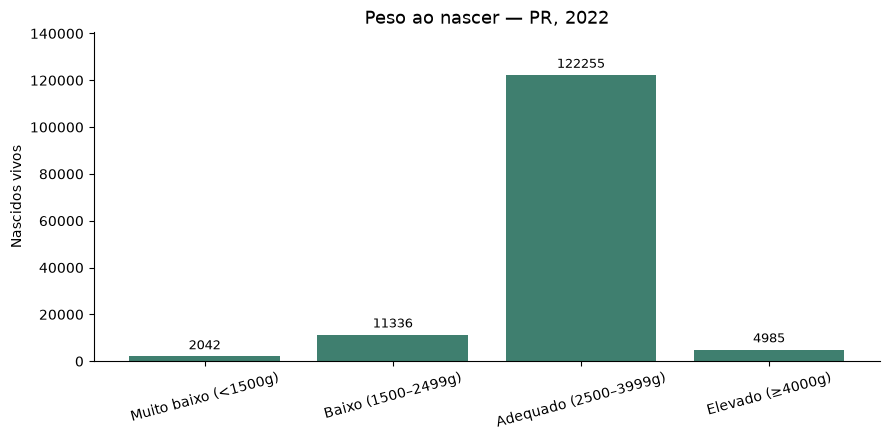

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
barras = ax.bar(distribuicao["Faixa de peso"].astype(str),
                distribuicao["Nascimentos"], color="#3f7f6f")
ax.bar_label(barras, padding=3, fontsize=9)

ax.set_title(f"Peso ao nascer — {UF}, {ANO}", fontsize=13)
ax.set_ylabel("Nascidos vivos")
ax.set_ylim(0, distribuicao["Nascimentos"].max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Passo 6 — Consultas de pré-natal

`CONSPRENAT` traz o número de consultas de pré-natal registradas.

In [9]:
if "CONSPRENAT" in nascimentos.columns:
    consultas = pd.to_numeric(nascimentos["CONSPRENAT"], errors="coerce")
    consultas = consultas[(consultas >= 0) & (consultas <= 40)]
    adequado = (consultas >= 7).mean() * 100
    print(f"Média de consultas de pré-natal: {consultas.mean():.1f}")
    print(f"Gestantes com 7 ou mais consultas: {adequado:.1f}%")
else:
    print("Coluna CONSPRENAT não disponível neste ano.")
    print("Colunas com 'PRENAT' no nome:",
          [c for c in nascimentos.columns if "PRENAT" in c.upper()])

Média de consultas de pré-natal: 9.8
Gestantes com 7 ou mais consultas: 86.0%


## Como adaptar

- **Outro estado ou ano:** mude `UF` e `ANO`.
- **Um município:** filtre `CODMUNRES` (código IBGE de residência da mãe).
- **Prematuridade:** a coluna `GESTACAO` traz a duração da gestação em semanas.
- **Idade da mãe:** `IDADEMAE` permite recortes por faixa etária, útil para
  acompanhar gravidez na adolescência.

## Verificação de sanidade

Toda análise deste repositório termina conferindo o próprio resultado. Não é
formalidade: uma mudança no catálogo do DATASUS já fez notebooks devolverem o
Brasil inteiro rotulado como um estado, **sem erro nenhum**. Falhar alto é
incômodo; acertar o formato e errar o número vira decisão errada.

In [ ]:
print("Verificações\n")
falhas = []


def conferir(numero, descricao, condicao, detalhe=""):
    marca = "confere" if condicao else "ATENÇÃO"
    print(f"{numero}. {descricao}{(' — ' + detalhe) if detalhe else ''}: {marca}")
    if not condicao:
        falhas.append(descricao)

def soma(x):
    """Soma numérica de escalar, Series ou DataFrame. Sempre devolve número."""
    import numpy as np
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    if isinstance(x, pd.DataFrame):
        return float(x.select_dtypes("number").to_numpy().sum())
    return float(pd.to_numeric(pd.Series(x), errors="coerce").sum())


conferir(1, "Vieram nascimentos", len(nascimentos) > 0,
         f"{len(nascimentos):,} nascidos vivos")
# CODIGO_UF e um DICIONARIO sigla -> codigo neste notebook.
_uf = CODIGO_UF[UF] if isinstance(CODIGO_UF, dict) else CODIGO_UF
conferir(2, "Todos são do estado pedido",
         set(nascimentos["CODMUNRES"].astype(str).str[:2].unique()) == {str(_uf)}
         if "CODMUNRES" in nascimentos.columns else True,
         f"código {_uf}")
# O Brasil tem ~56% de cesareas — o maior indice do mundo entre paises grandes.
# por_parto pode ser Series ou DataFrame: soma() aceita as duas formas, e o
# rotulo do parto cesareo e procurado sem depender do acento exato.
if len(por_parto):
    _tot = soma(por_parto)
    _serie = (por_parto.iloc[:, 0] if isinstance(por_parto, pd.DataFrame)
              else por_parto)
    _ces = soma([v for k, v in _serie.items()
                 if "cesar" in str(k).lower() or "cesár" in str(k).lower()])
    if _ces:
        conferir(3, "Proporção de cesáreas entre 30% e 80%",
                 30 <= _ces / _tot * 100 <= 80, f"{_ces / _tot * 100:.1f}%")
# Baixo peso ao nascer fica perto de 9% no Brasil
_baixo = pd.to_numeric(nascimentos["PESO"], errors="coerce")
_pct = float((_baixo < 2500).mean() * 100)
conferir(4, "Baixo peso ao nascer entre 5% e 15%", 5 <= _pct <= 15, f"{_pct:.1f}%")

print()
if falhas:
    print("ATENÇÃO: revise antes de usar estes números —", falhas)
else:
    print("Tudo confere.")

---
*Notebook do projeto [PySusNoCode](https://github.com/cartaproale/PySusNoCode) —
um produto [Kraemer Academy](https://kraemeracademy.net).
Validado com dados reais do DATASUS.*